## Telco Customer Churn Predicition Using ML Models

In this project I aimed to predict whether the customer is going to churn or not. I used classical ML approches such as DecisionTreeClassifier, XGBClassifier and Logistic Regression. To use most suitable parameters I used RandomizedSearchCV. I also used accuracy_score, precision_score, recall_score,f1_score,confusion_matrix,classification_report to evaluate clearly success and classification errors of the models.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score,confusion_matrix,classification_report
import missingno as msno

## Data Analysis Part

In this part, I analyzed the dataset to gain a better understanding of its structure, patterns, and relationships between variables. I used descriptive statistics and Python visualization libraries to explore the data more effectively.

This analysis helped me observe feature distributions, compare churn and non-churn customers, and identify important factors that may affect customer churn.
 

In [53]:
df= pd.read_csv(r'/Users/huseyinbilgili/Desktop/python_files/Mat381e term project/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df['TotalCharges']

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: str

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
round(df.isnull().sum()/df.shape[0],3)

customerID          0.000
gender              0.000
SeniorCitizen       0.000
Partner             0.000
Dependents          0.000
tenure              0.000
PhoneService        0.000
MultipleLines       0.000
InternetService     0.000
OnlineSecurity      0.000
OnlineBackup        0.000
DeviceProtection    0.000
TechSupport         0.000
StreamingTV         0.000
StreamingMovies     0.000
Contract            0.000
PaperlessBilling    0.000
PaymentMethod       0.000
MonthlyCharges      0.000
TotalCharges        0.002
Churn               0.000
dtype: float64

In [11]:
df[df['TotalCharges'].isnull()][['TotalCharges','tenure','MonthlyCharges']].head()

,TotalCharges,tenure,MonthlyCharges
488,NaN,0,52.55
753,NaN,0,20.25
936,NaN,0,80.85
1082,NaN,0,25.75
1340,NaN,0,56.05


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


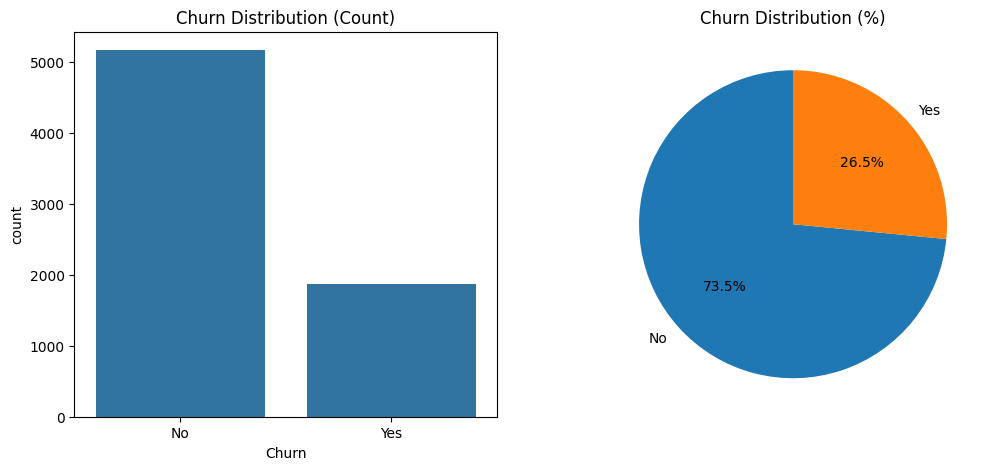

In [12]:


fig, axes = plt.subplots(1,2,figsize=(12,5))
sns.countplot(data=df, x="Churn",ax=axes[0])
axes[0].set_title('Churn Distribution (Count)')
churn_counts = df['Churn'].value_counts()

axes[1].pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Churn Distribution (%)')
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

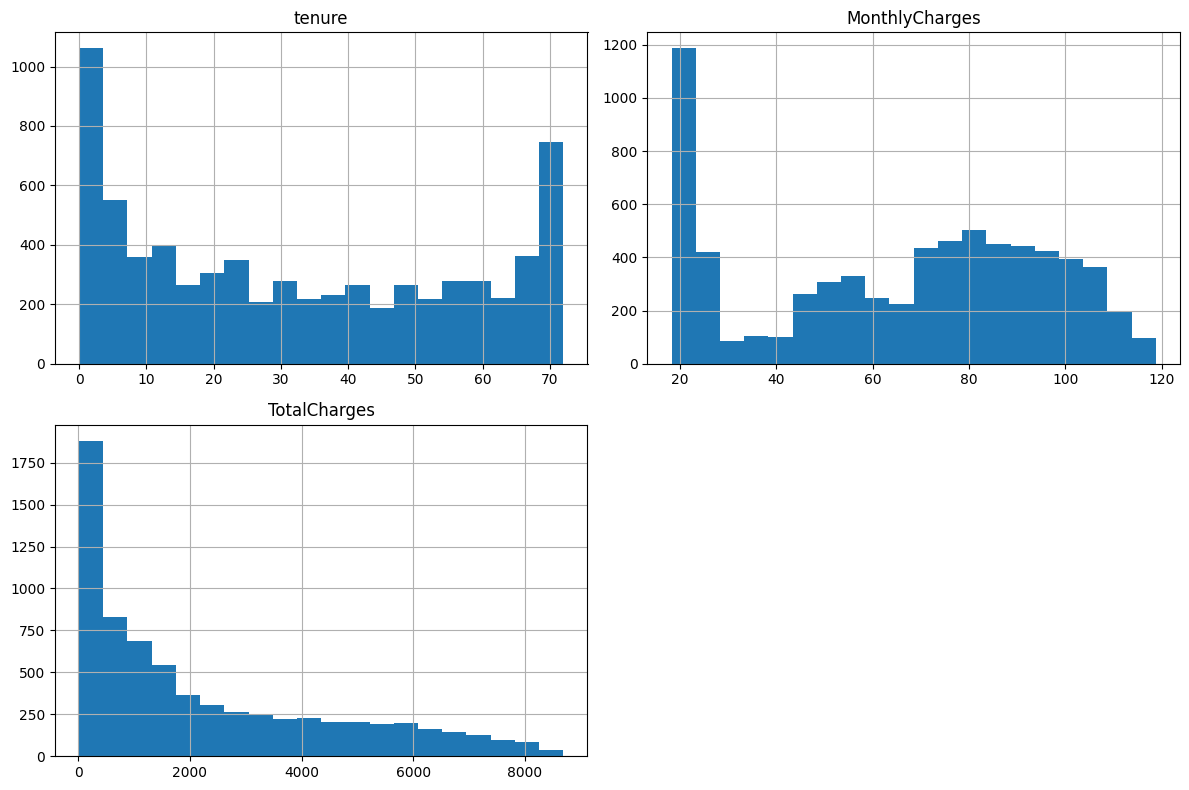

In [13]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df[numeric_cols].hist(figsize=(12,8),bins=20)
plt.tight_layout()
plt.show()

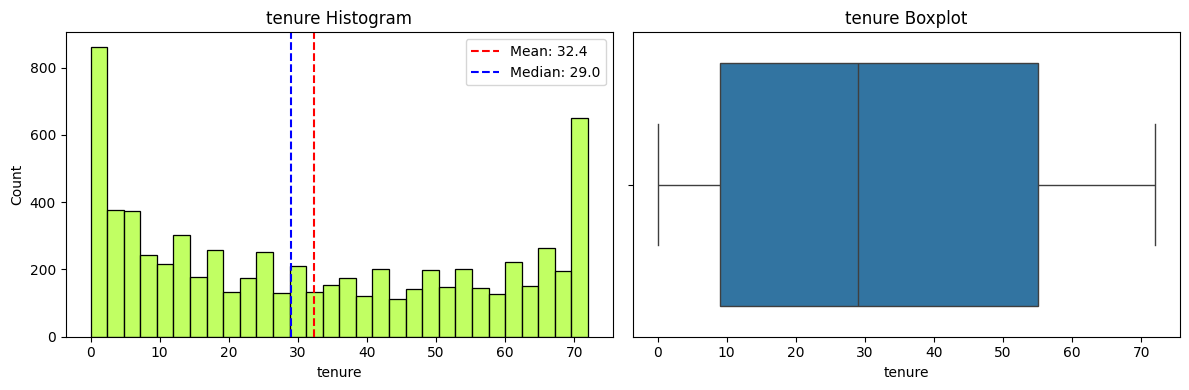

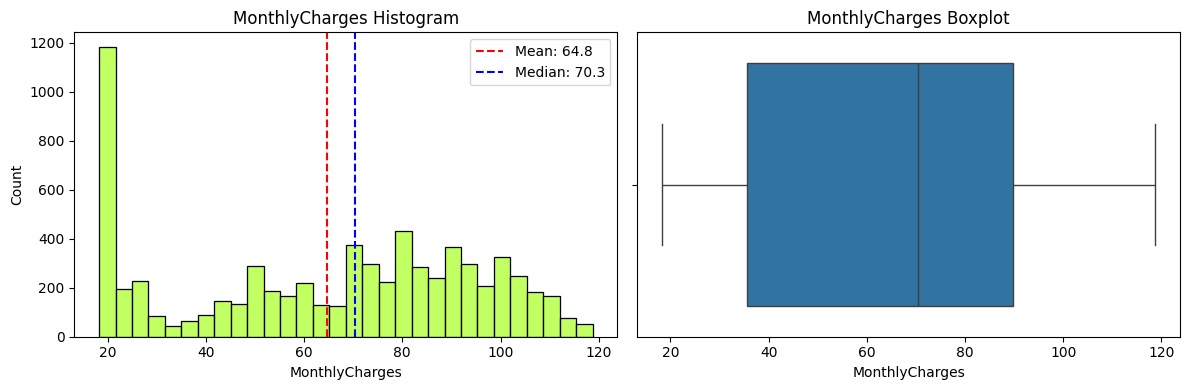

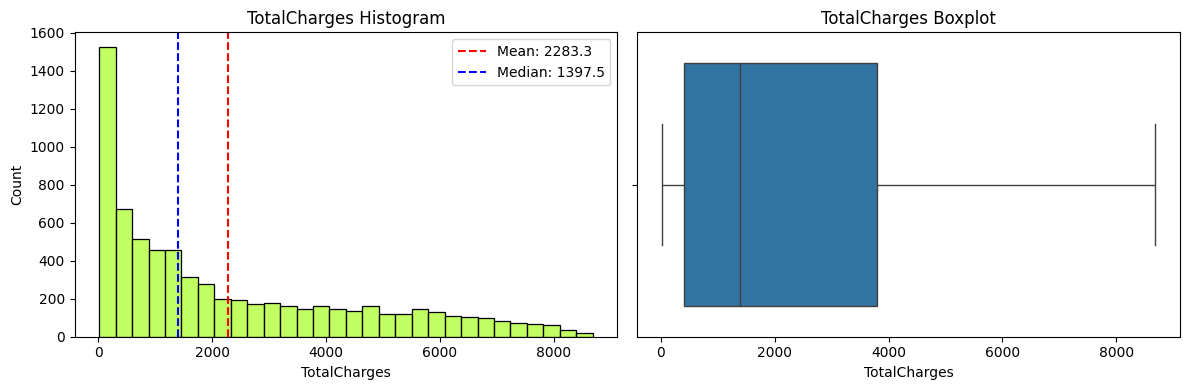

In [14]:
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(df[col], bins=30,  ax=axes[0], color='greenyellow')
    axes[0].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[0].axvline(df[col].median(), color='blue', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[0].set_title(f'{col} Histogram')
    axes[0].legend()

    # Boxplot (DÜZELTİLDİ)
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'{col} Boxplot')

    plt.tight_layout()
    plt.show()
    
    

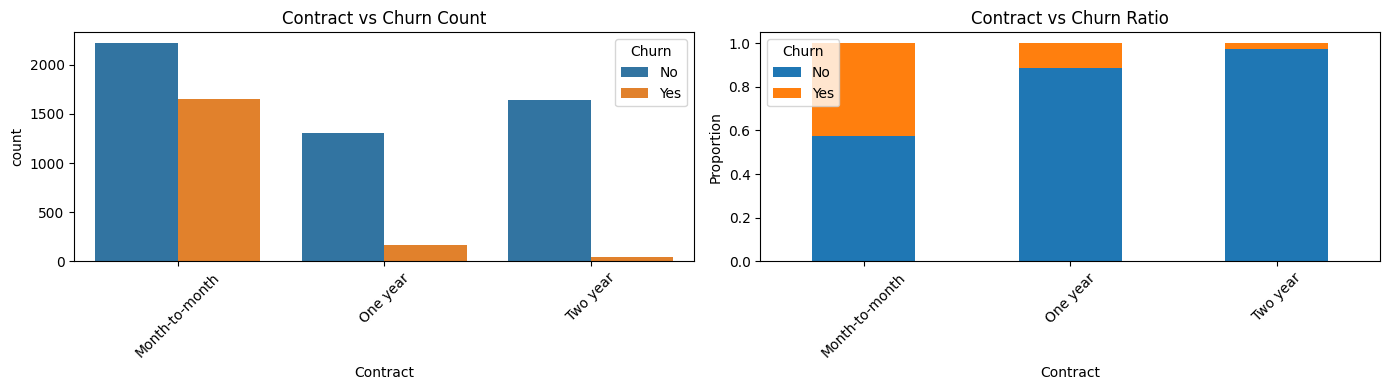

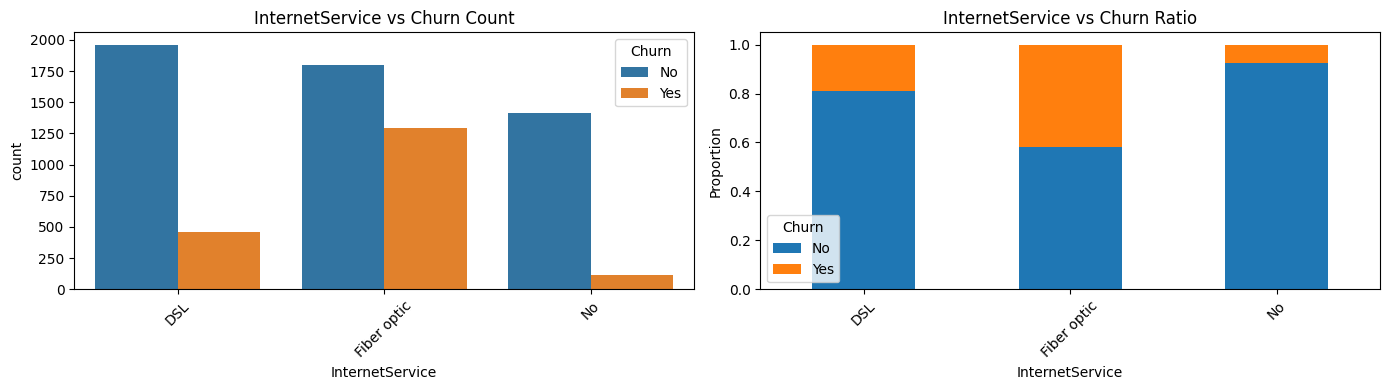

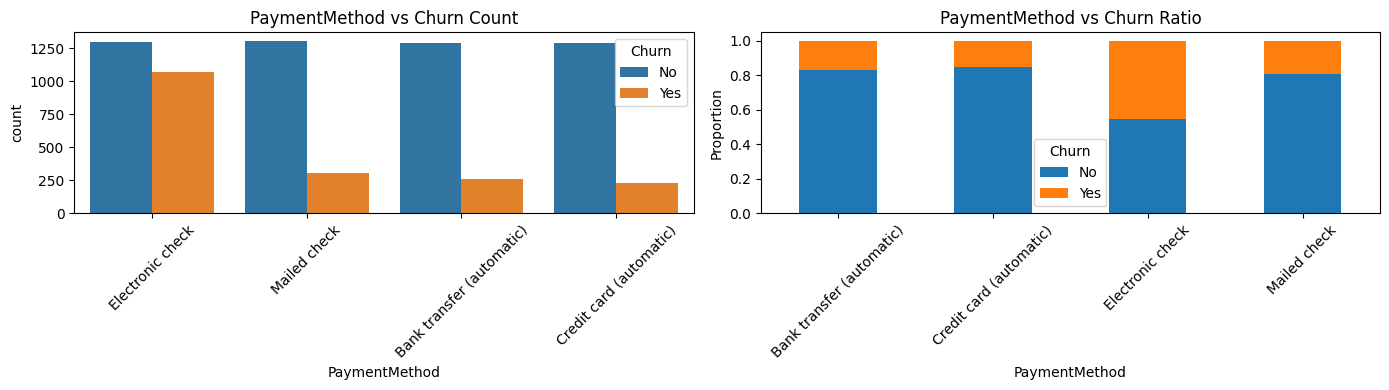

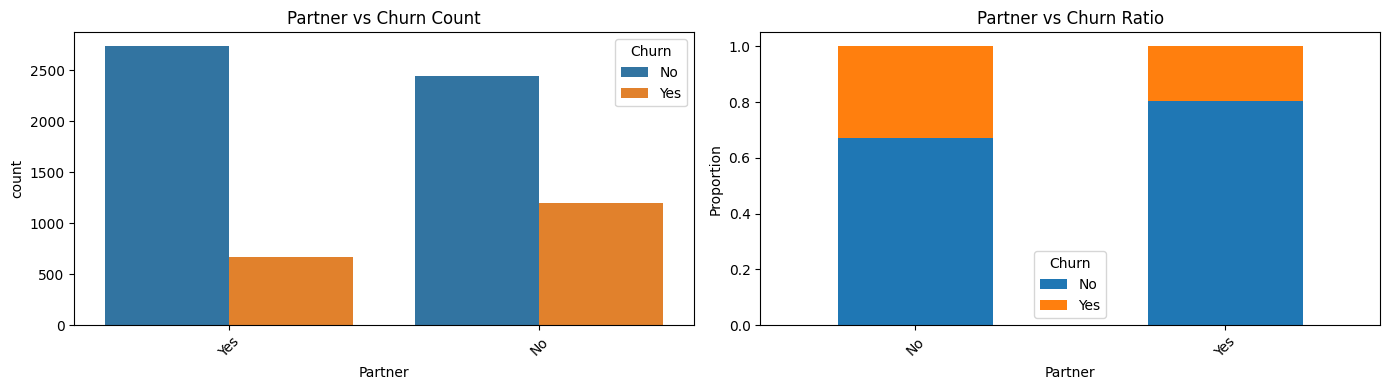

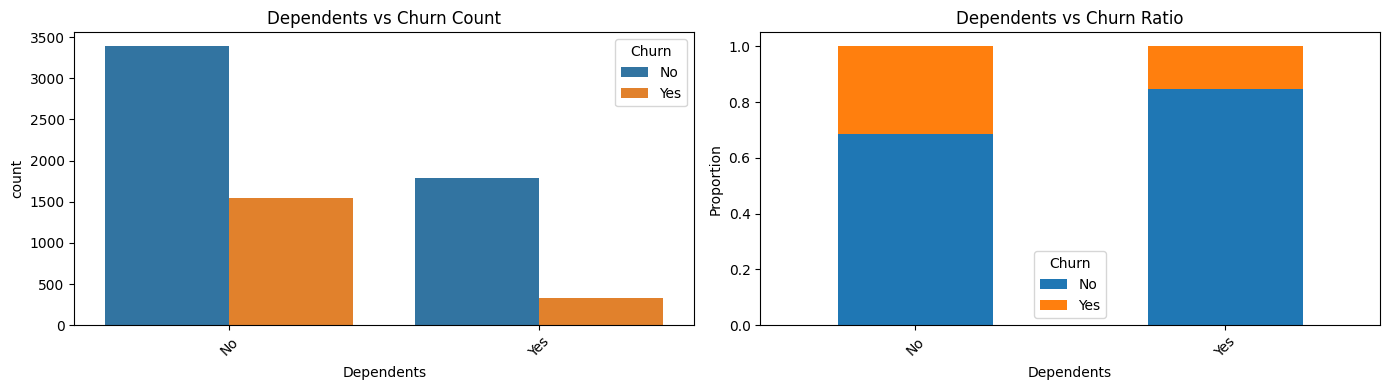

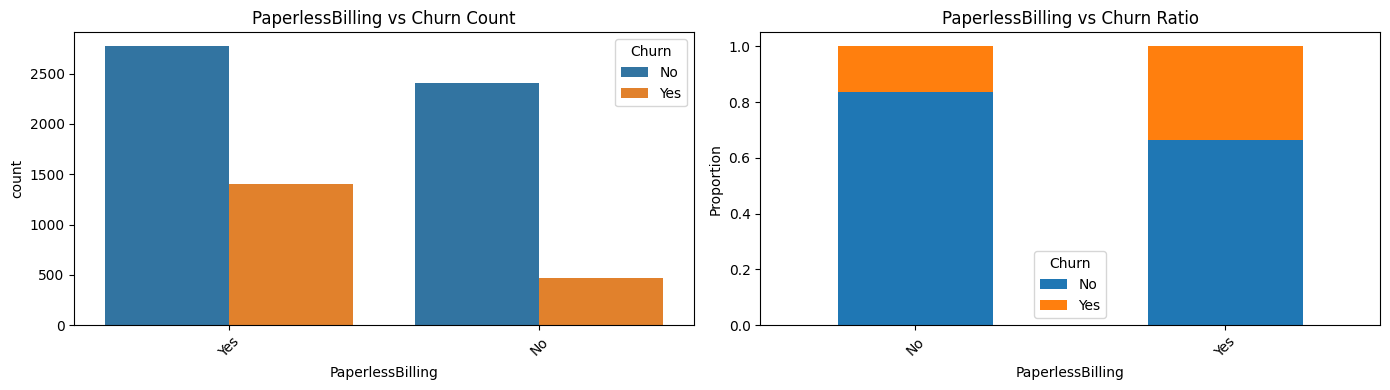

In [15]:
cat_cols =['Contract','InternetService','PaymentMethod','Partner','Dependents','PaperlessBilling']
for col in cat_cols:
    fig, axes = plt.subplots(1,2,figsize=(14,4))
    sns.countplot(data=df,x=col,hue='Churn',ax=axes[0])
    axes[0].set_title(f'{col} vs Churn Count')
    axes[0].tick_params(axis='x', rotation=45)

    ct= pd.crosstab(df[col],df['Churn'],normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[1])
    axes[1].set_title(f'{col} vs Churn Ratio')
    axes[1].tick_params(axis='x',rotation=45)
    axes[1].set_ylabel('Proportion')

    plt.tight_layout()
    plt.show()

In [16]:
pd.crosstab(df['Contract'],df['Churn'],normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


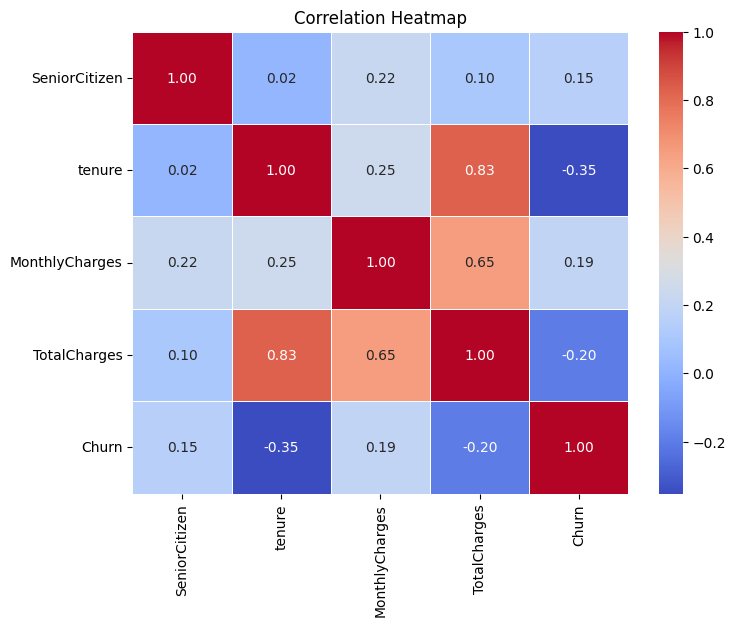

In [17]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

matrix_corr= df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(matrix_corr,annot=True,cmap='coolwarm',fmt='.2f',linewidth=0.5)
plt.title('Correlation Heatmap')
plt.show()

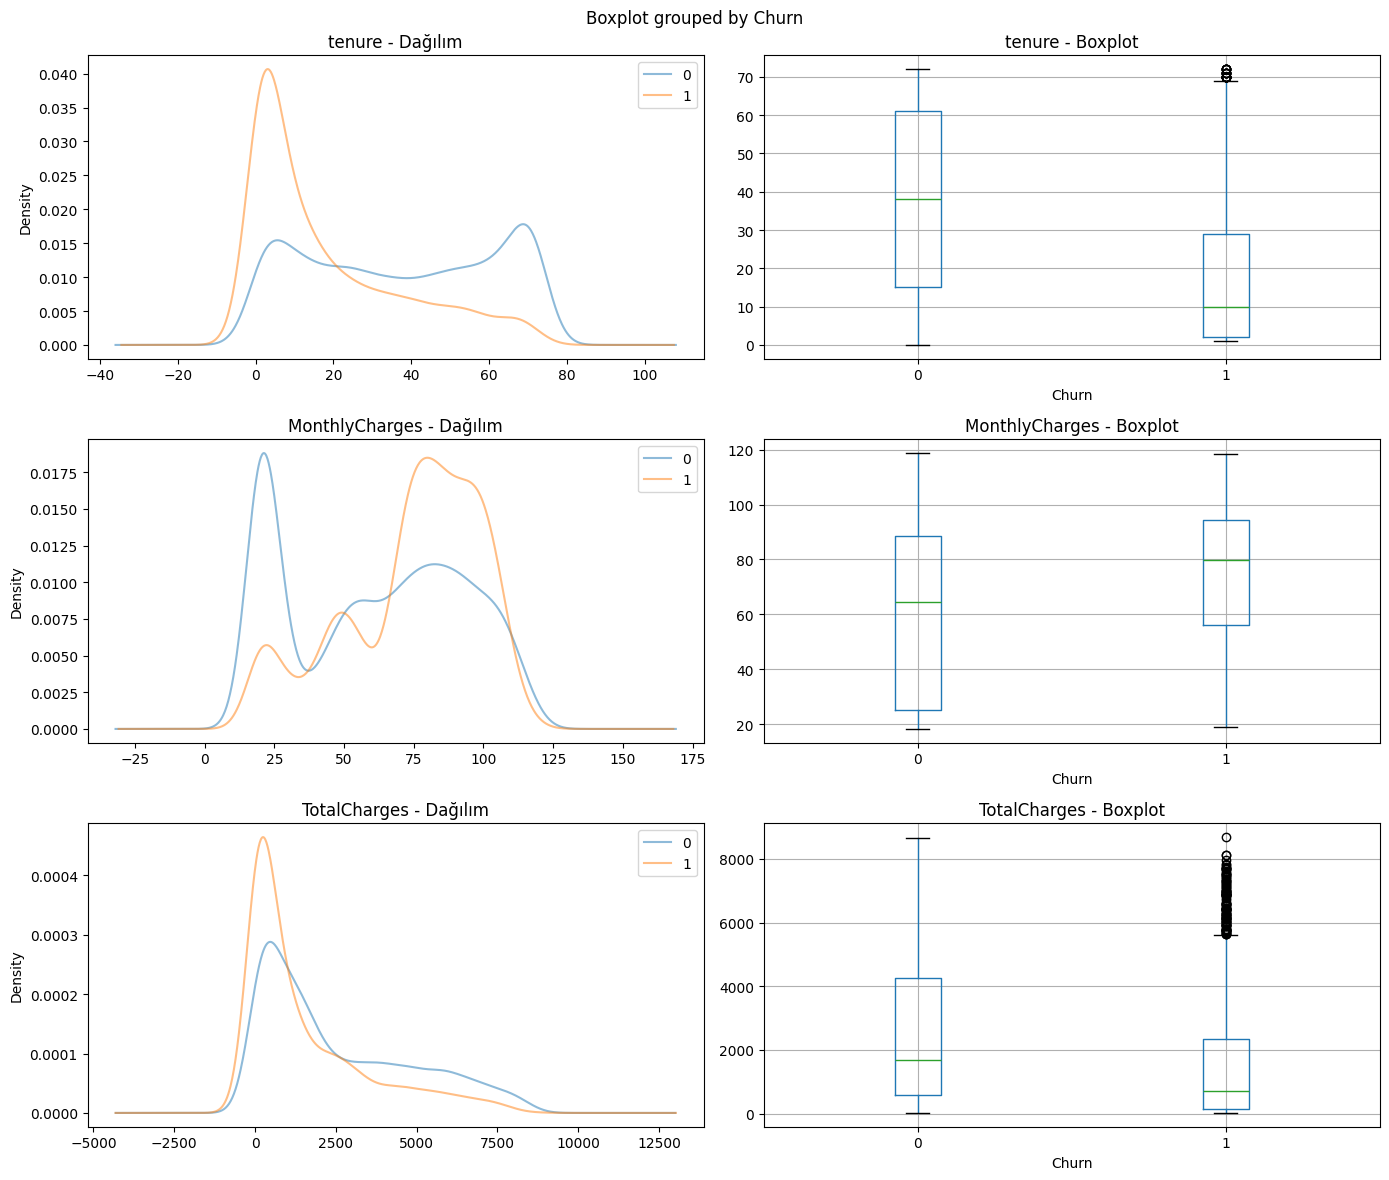

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include='number').columns.drop(['Churn','SeniorCitizen'])

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, len(numeric_cols)*4))

for i, col in enumerate(numeric_cols):
    # Histogram - churn'e göre ayrı
    df.groupby('Churn')[col].plot(kind='kde', alpha=0.5, ax=axes[i,0], legend=True)
    axes[i,0].set_title(f'{col} - Dağılım')
    
    # Boxplot - farkı net gösterir
    df.boxplot(column=col, by='Churn', ax=axes[i,1])
    axes[i,1].set_title(f'{col} - Boxplot')

plt.tight_layout()

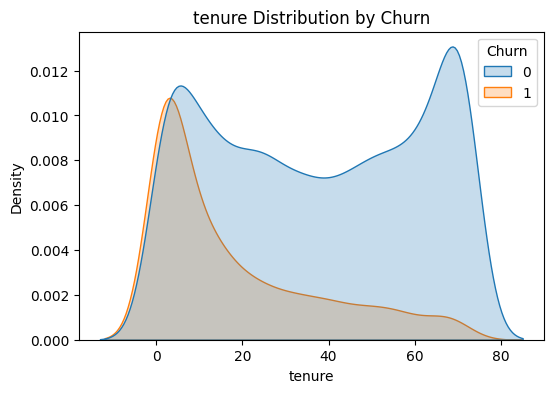

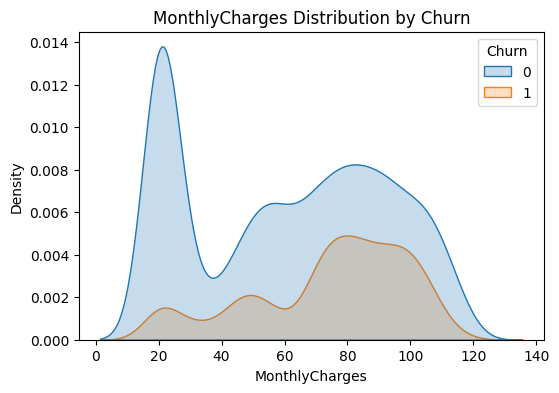

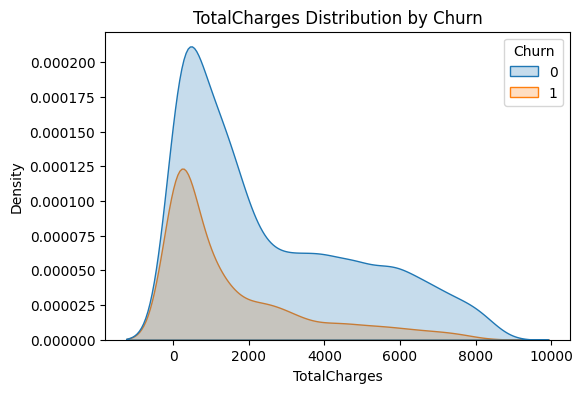

In [19]:

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue="Churn", fill=True)
    plt.title(f"{col} Distribution by Churn")
    plt.show()


/var/folders/5y/qbwsjz7x2mxf6673033s_3xw0000gn/T/ipykernel_5262/509536674.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=col, ax=ax,palette=['#3498db','#e74c3c'])
/var/folders/5y/qbwsjz7x2mxf6673033s_3xw0000gn/T/ipykernel_5262/509536674.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=col, ax=ax,palette=['#3498db','#e74c3c'])
/var/folders/5y/qbwsjz7x2mxf6673033s_3xw0000gn/T/ipykernel_5262/509536674.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=col, ax=ax,palette=

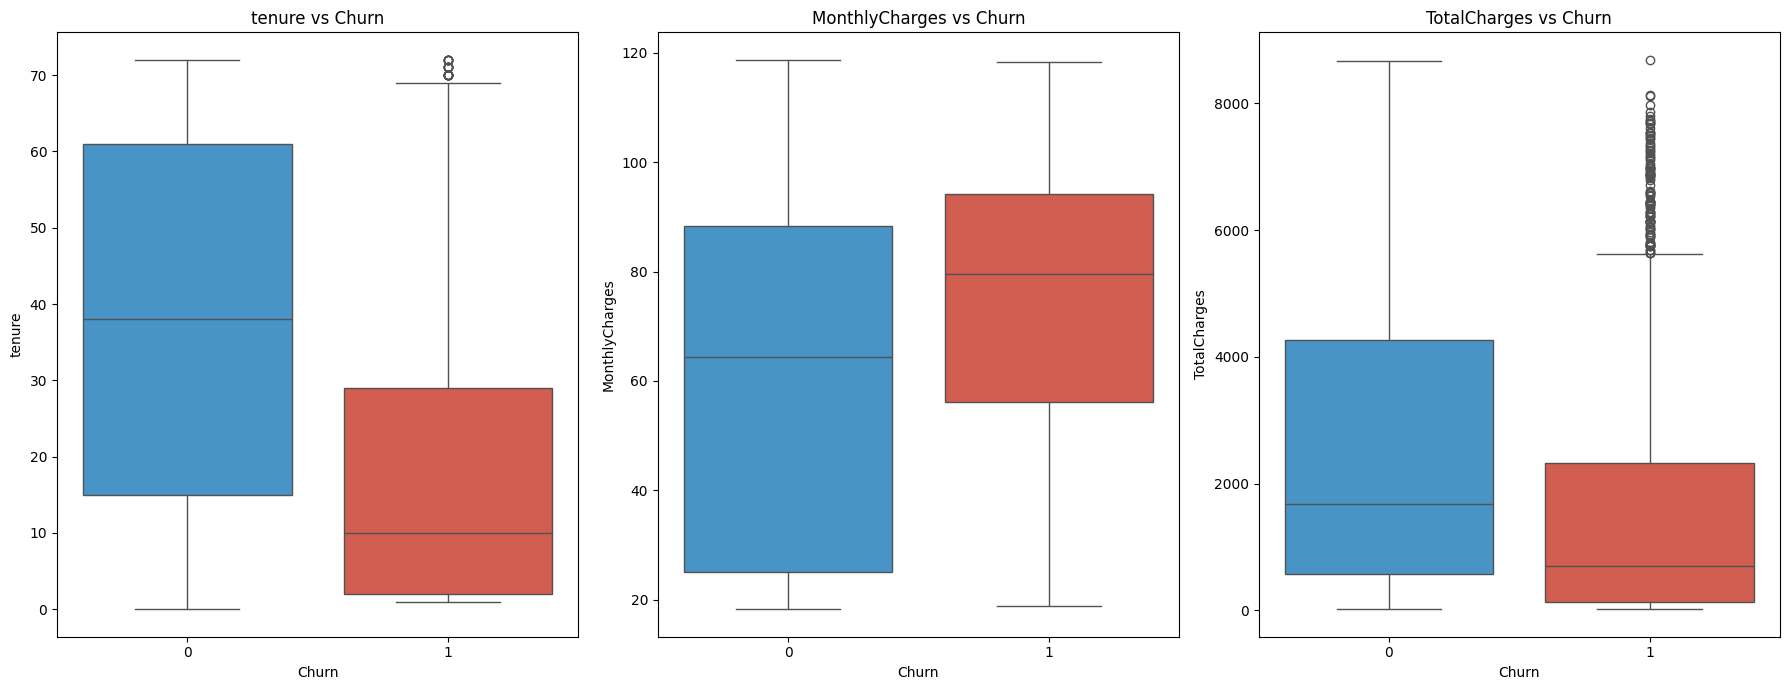

In [20]:

fig, axes = plt.subplots(1, 3, figsize=(18,7))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax,palette=['#3498db','#e74c3c'])
    ax.set_title(f"{col} vs Churn")

plt.tight_layout()
plt.show()

In [21]:
df[df['TotalCharges'].isnull()]


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,0
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,0
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,0
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,0
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,0
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,0
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,0
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,0
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,0
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,0


## Data Preprocessing

Before model training, I applied several preprocessing steps. First, the TotalCharges column was converted from object type to numeric type. After this conversion, 11 missing values appeared because some customers had zero tenure. Since these customers had not generated any total charge yet, I filled their missing TotalCharges values with 0.

I removed the customerID column because it is only an identifier and does not provide predictive information. The target variable Churn was converted into binary values, where Yes was mapped to 1 and No was mapped to 0.

The dataset was split into training and test sets using stratified sampling to preserve the churn ratio in both sets. Categorical variables were encoded using one-hot encoding, and numerical variables were scaled using StandardScaler.

In [22]:
X= df.drop(columns=['Churn','customerID'])
y= df['Churn']

X_train, X_test,y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=17,stratify=y)


In [23]:
X_train[X_train['TotalCharges'].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN


In [24]:
print(cat_cols)
print(numeric_cols)

['Contract', 'InternetService', 'PaymentMethod', 'Partner', 'Dependents', 'PaperlessBilling']
Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')


In [25]:
for col in numeric_cols:
    Q1= X_train[col].quantile(0.25)
    Q3=X_train[col].quantile(0.75)
    IQR= Q3-Q1

    lower_bound= Q1-1.5*IQR
    upper_bound= Q3+1.5 * IQR
    outliers_train =X_train[(X_train[col]< lower_bound) | (X_train[col]>upper_bound)]
    print(f'{col}')
    print(f'Outlier count in train {outliers_train.shape[0]}')
    

tenure
Outlier count in train 0
MonthlyCharges
Outlier count in train 0
TotalCharges
Outlier count in train 0


In [26]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

/var/folders/5y/qbwsjz7x2mxf6673033s_3xw0000gn/T/ipykernel_5262/429679037.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()


In [27]:
X_train[X_train['tenure']==0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN


In [28]:
X_train.loc[
    (X_train["tenure"] == 0) & (X_train["TotalCharges"].isnull()),
    "TotalCharges"
] = 0

X_test.loc[
    (X_test["tenure"] == 0) & (X_test["TotalCharges"].isnull()),
    "TotalCharges"
] = 0

In [29]:
X_train_encoded = pd.get_dummies(
    X_train,
    columns=cat_cols,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=cat_cols,
    drop_first=True
)
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

In [30]:
X_train =X_train_encoded
X_test= X_test_encoded

In [31]:
scaler =StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [32]:
X_train

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
6225,0,1.614063,1.372277,2.321710,True,True,True,True,False,True,...,False,True,False,False,False,True,True,True,False,False
2511,1,-0.140275,0.839161,0.161692,True,True,False,True,False,False,...,False,False,False,True,True,False,False,False,False,False
2603,0,1.614063,1.665490,2.740343,False,False,False,True,False,True,...,False,True,False,True,False,True,True,False,True,False
2939,1,-0.833850,0.629247,-0.556688,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
1479,0,0.471703,-0.528614,-0.011263,False,False,False,False,True,False,...,False,True,False,True,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6812,1,0.512502,0.692554,0.656846,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
100,0,-1.282634,-1.489888,-1.002454,True,False,False,True,False,False,...,True,False,True,False,False,False,False,False,False,True
3305,1,0.226912,0.994098,0.601608,True,False,False,True,False,True,...,False,True,False,True,False,False,False,False,True,False
6087,0,-0.262671,-0.831823,-0.559337,True,False,True,False,True,False,...,False,True,False,False,True,False,True,False,False,False


In [33]:
X_test

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4471,1,0.349308,0.627581,0.434062,True,True,False,True,False,True,...,False,False,False,False,False,False,True,False,False,False
3035,1,-0.303469,0.146111,-0.210800,False,True,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
4656,0,-0.425865,0.362689,-0.298226,False,True,True,True,False,True,...,False,False,False,False,False,False,True,False,False,False
5619,1,-0.507462,0.869149,-0.190312,False,True,False,True,False,False,...,False,True,False,True,True,False,True,False,False,False
4338,1,-1.119440,-0.650231,-0.916551,True,False,False,False,True,False,...,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,0,-0.262671,-1.524873,-0.783644,True,True,True,True,False,False,...,True,False,True,False,False,True,True,True,False,False
6728,0,1.614063,1.673820,2.675436,False,True,False,True,False,True,...,False,True,False,True,False,True,False,False,True,False
2242,0,0.471703,-1.334951,-0.563819,True,True,True,True,False,True,...,True,False,True,False,True,False,False,False,True,False
5027,1,-0.915447,0.687556,-0.635284,True,True,False,True,False,True,...,False,False,False,True,False,False,False,False,True,False


In [34]:
print("Train missing:", X_train.isnull().sum().sum())
print("Test missing:", X_test.isnull().sum().sum())

print("Same columns:", X_train.columns.equals(X_test.columns))

print(X_train.dtypes.value_counts())
print(X_test.dtypes.value_counts())

Train missing: 0
Test missing: 0
Same columns: True
bool       26
float64     3
int64       1
Name: count, dtype: int64
bool       26
float64     3
int64       1
Name: count, dtype: int64


## Model Training and Hyperparameter Tuning

I trained three different machine learning models: Logistic Regression, Decision Tree Classifier, and XGBoost Classifier.

For Logistic Regression and Decision Tree, I used GridSearchCV to find the best hyperparameters based on F1-score. For XGBoost, I used RandomizedSearchCV with StratifiedKFold cross-validation and optimized the model based on ROC-AUC score.

Hyperparameter tuning helped improve the models and made the comparison more reliable.

In [35]:
lr_default =  LogisticRegression(max_iter=1000,random_state=17)
lr_default.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",17
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [36]:
y_pred_lr_default=lr_default.predict(X_test)

In [37]:
dt_default= DecisionTreeClassifier(random_state=17)
dt_default.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",17
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [38]:
y_pred_tree_default= dt_default.predict(X_test)

In [39]:
lr_hp_op = LogisticRegression(max_iter=1000,random_state=17)

param_grid_log = {
    "C": [0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"]
}

grid_lg =GridSearchCV(
    estimator=lr_hp_op,
    param_grid= param_grid_log,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lg.fit(X_train,y_train)
print('Best params:')
print(grid_lg.best_params_)
print('\nBest CV F1 Score:')
print(grid_lg.best_score_)
lr_final =  grid_lg.best_estimator_

Best params:
{'C': 0.1, 'class_weight': 'balanced'}

Best CV F1 Score:
0.6260489177017818


In [40]:
tree_model= DecisionTreeClassifier(random_state=17)

param_grid_tree = {
    'criterion' : ['gini','entropy'],
    'max_depth' : [3,5,7,10],
    'min_samples_split':[2,5,10,20],
    'min_samples_leaf':[1,2,5,10],
    'class_weight':['balanced']    
}
grid_dt= GridSearchCV(
    estimator=tree_model,
    param_grid =param_grid_tree,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_dt.fit(X_train,y_train)

print('Best Decision Tree Parameters:')
print(grid_dt.best_params_)

print('\nBest Decision Tree CV F1 Score:')
print(grid_dt.best_score_)

best_tree_model =grid_dt.best_estimator_
y_pred_tree_grid = best_tree_model.predict(X_test)

Best Decision Tree Parameters:
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 20}

Best Decision Tree CV F1 Score:
0.6052240799453272


In [41]:
print("Decision Tree - GridSearchCV Results")
print("-" * 50)

print("Accuracy:", accuracy_score(y_test, y_pred_tree_grid))
print("Precision:", precision_score(y_test, y_pred_tree_grid))
print("Recall:", recall_score(y_test, y_pred_tree_grid))
print("F1-score:", f1_score(y_test, y_pred_tree_grid))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree_grid))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree_grid))

Decision Tree - GridSearchCV Results
--------------------------------------------------
Accuracy: 0.7388218594748048
Precision: 0.504950495049505
Recall: 0.8181818181818182
F1-score: 0.6244897959183674

Confusion Matrix:
[[735 300]
 [ 68 306]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      1035
           1       0.50      0.82      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.75      1409



In [42]:
xgb_model =XGBClassifier()
xgb_model.fit(X_train,y_train)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [43]:
params = {'min_child_weight':[1,5,10],
         'gamma':[0.5,1,1.5,2,5],
         'subsample':[0.6,0.8,1.0],
         'colsample_bytree':[0.6,0.8,1.0],
         'max_depth':[3,4,5]
         }

In [44]:
folds =4
param_comb =5
skf =StratifiedKFold(n_splits =folds,shuffle=True,random_state=17)

random_search =RandomizedSearchCV(xgb_model,param_distributions=params, n_iter=param_comb,scoring ='roc_auc',n_jobs=4,cv=skf.split(X_train,y_train),verbose=True,random_state=17)

random_search.fit(X_train,y_train)

Fitting 4 folds for each of 5 candidates, totalling 20 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0.5, 1, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ver

In [45]:
random_search.cv_results_

{'mean_fit_time': array([0.05334866, 0.055529  , 0.03121585, 0.04710776, 0.03777534]),
 'std_fit_time': array([0.00066926, 0.00130661, 0.00066373, 0.00027503, 0.00068847]),
 'mean_score_time': array([0.00287724, 0.00274831, 0.00233942, 0.00248176, 0.00233436]),
 'std_score_time': array([1.02967158e-04, 2.94257857e-04, 7.23150267e-05, 9.03932491e-05,
        8.87649052e-05]),
 'param_subsample': masked_array(data=[0.8, 0.6, 1.0, 0.8, 0.8],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'param_min_child_weight': masked_array(data=[1, 1, 10, 10, 1],
              mask=[False, False, False, False, False],
        fill_value=999999),
 'param_max_depth': masked_array(data=[3, 5, 5, 3, 3],
              mask=[False, False, False, False, False],
        fill_value=999999),
 'param_gamma': masked_array(data=[0.5, 2.0, 1.5, 1.0, 2.0],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'param_colsample_bytree': masked_array(dat

In [46]:
xgb_final= random_search.best_estimator_

## Model Evaluation

The models were evaluated using accuracy, precision, recall, and F1-score. Since the dataset is imbalanced, I focused especially on recall and F1-score instead of only accuracy.

XGBoost achieved the highest accuracy and precision, which means it made fewer false positive predictions. However, its recall was lower than the other models, meaning it missed more actual churn customers.

Logistic Regression achieved the best F1-score and a high recall value. This means it provided the best balance between correctly identifying churn customers and avoiding too many false positives.

Decision Tree achieved the highest recall, but its precision was lower. This means it detected many churn customers, but it also incorrectly classified more non-churn customers as churn.

In [47]:
models = {'XGBoost':xgb_final,'Logistic Regression':lr_final,'Decision Tree Classifier':best_tree_model}

accuracy_scores =[]
precision_scores= []
recall_scores= []
f1_scores=[]
for model in models.values():
    y_pred= model.predict(X_test)
    accuracy =accuracy_score(y_test,y_pred)
    accuracy_scores.append(accuracy)
    precision = precision_score(y_test,y_pred)
    precision_scores.append(precision)
    recall = recall_score(y_test,y_pred)
    recall_scores.append(recall)
    f1 = f1_score(y_test,y_pred)
    f1_scores.append(f1)

In [48]:
accuracy

0.7388218594748048

In [49]:
len(models.keys())

3

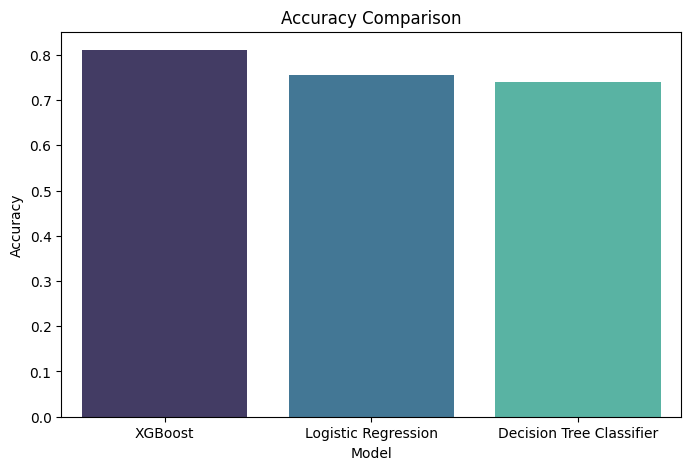

In [50]:
df_plot = pd.DataFrame({
    "Model": list(models.keys()),
    'Accuracy' : accuracy_scores,
    'F1-Scores': f1_scores,
    'Presicion': precision_scores,
    'Recall': recall_scores
})
plt.figure(figsize=(8,5))

sns.barplot(data=df_plot,x='Model',y='Accuracy',hue='Model',palette='mako')

plt.title('Accuracy Comparison')
plt.show()


In [51]:
df_plot

,Model,Accuracy,F1-Scores,Presicion,Recall
0,XGBoost,0.810504,0.603269,0.678930,0.542781
1,Logistic Regression,0.755855,0.635593,0.526316,0.802139
2,Decision Tree Classifier,0.738822,0.624490,0.504950,0.818182


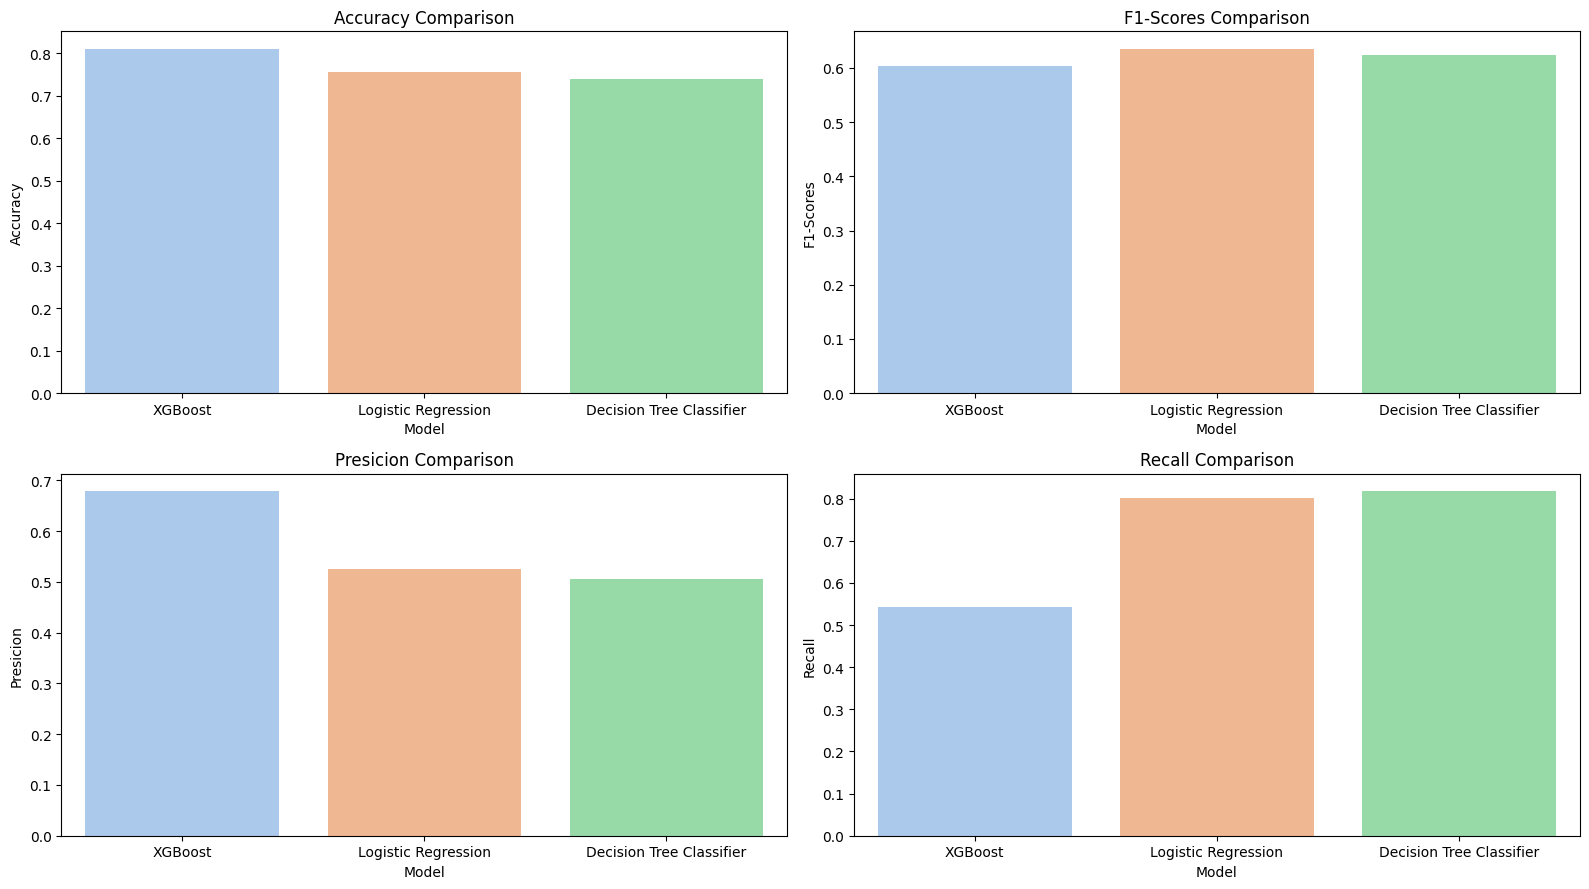

In [52]:
fig, axes = plt.subplots(2,2,figsize=(16,9))
axes= axes.flatten()
for ax, col in zip(axes,df_plot.columns.to_list()[1:]):
    sns.barplot(data=df_plot,x='Model',y=col,ax=ax,hue='Model',palette='pastel')
    ax.set_title(f'{col} Comparison')
plt.tight_layout()
plt.show()

## Conclusion

In conclusion, XGBoost performed best in terms of accuracy, but Logistic Regression provided the most balanced performance according to F1-score. Since customer churn prediction focuses on identifying customers who are likely to leave, recall and F1-score are more important than accuracy alone.

Therefore, Logistic Regression can be considered the most suitable model for this project because it gives a strong balance between recall and precision while remaining simple and interpretable.